In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
df = pd.read_csv(
    r"D:\Guvi\Projects\ride_flow_ai\data\preprocessed\cleaned_rides.csv"
)

print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2024-01-01 00:57:55   2024-01-01 01:17:43              1.0   
1         1  2024-01-01 00:03:00   2024-01-01 00:09:36              1.0   
2         1  2024-01-01 00:17:06   2024-01-01 00:35:01              1.0   
3         1  2024-01-01 00:36:38   2024-01-01 00:44:56              1.0   
4         1  2024-01-01 00:46:51   2024-01-01 00:52:57              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.72         1.0                  N           186            79   
1           1.80         1.0                  N           140           236   
2           4.70         1.0                  N           236            79   
3           1.40         1.0                  N            79           211   
4           0.80         1.0                  N           211           148   

   payment_type  ...  improvement_surcharge  total_amount  \
0            

In [3]:
print(df.shape)

print(df.info())

(99970, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99970 entries, 0 to 99969
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               99970 non-null  int64  
 1   tpep_pickup_datetime   99970 non-null  object 
 2   tpep_dropoff_datetime  99970 non-null  object 
 3   passenger_count        99970 non-null  float64
 4   trip_distance          99970 non-null  float64
 5   RatecodeID             99970 non-null  float64
 6   store_and_fwd_flag     99970 non-null  object 
 7   PULocationID           99970 non-null  int64  
 8   DOLocationID           99970 non-null  int64  
 9   payment_type           99970 non-null  int64  
 10  fare_amount            99970 non-null  float64
 11  extra                  99970 non-null  float64
 12  mta_tax                99970 non-null  float64
 13  tip_amount             99970 non-null  float64
 14  tolls_amount           99970 non-null  flo

In [4]:
hourly_rides = (
    df.groupby('pickup_hour')
    .size()
)

print(hourly_rides)

pickup_hour
0     6460
1     6160
2     5723
3     4160
4     2372
5     1665
6     2220
7     3605
8     4422
9     5155
10    6101
11    7004
12    7705
13    6326
14    3827
15    3970
16    4147
17    3662
18    3480
19    3179
20    2741
21    2313
22    2105
23    1468
dtype: int64


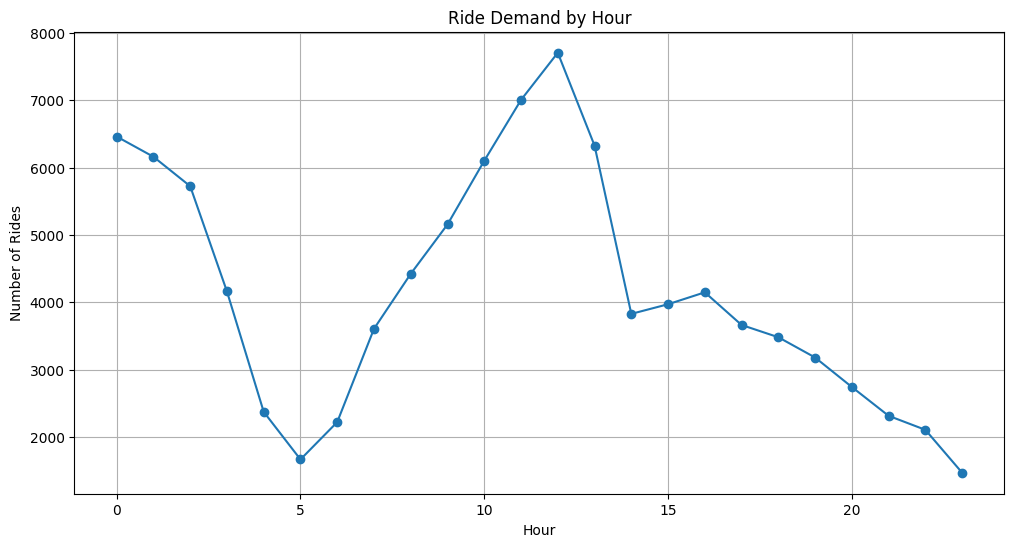

In [5]:
plt.figure(figsize=(12,6))

hourly_rides.plot(
    kind='line',
    marker='o'
)

plt.title("Ride Demand by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Rides")

plt.grid(True)

plt.show()

In [6]:
top_zones = (
    df['PULocationID']
    .value_counts()
    .head(10)
)

print(top_zones)

PULocationID
132    8031
186    4301
161    4073
138    3879
237    3360
162    3345
48     3103
236    3089
230    3057
170    2945
Name: count, dtype: int64


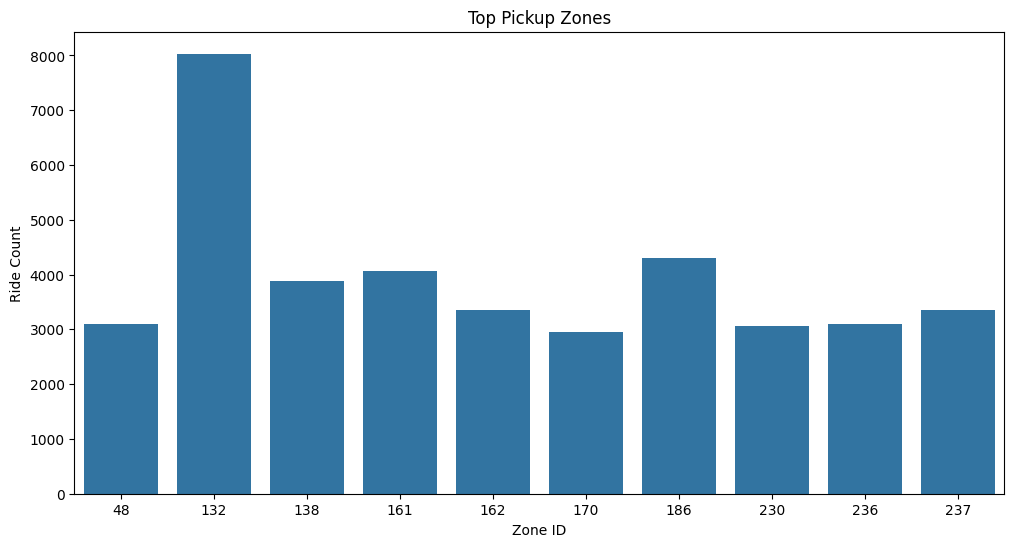

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_zones.index,
    y=top_zones.values
)

plt.title("Top Pickup Zones")

plt.xlabel("Zone ID")

plt.ylabel("Ride Count")

plt.show()

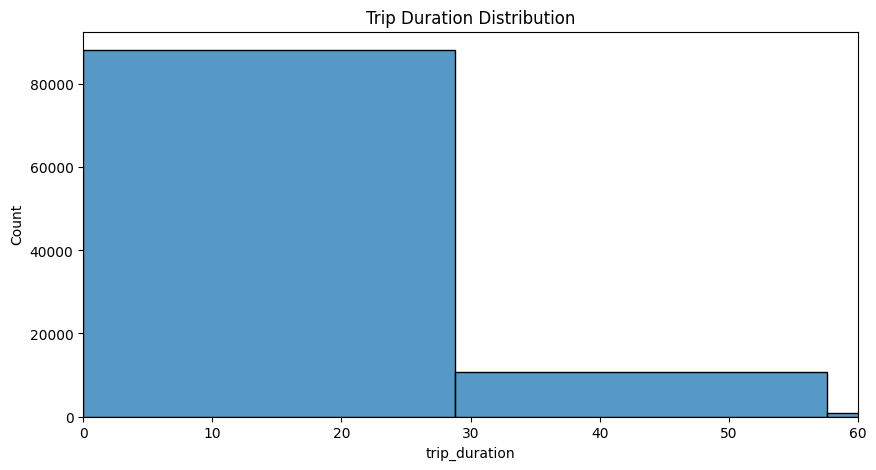

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['trip_duration'],
    bins=50
)

plt.title("Trip Duration Distribution")

plt.xlim(0,60)

plt.show()

In [9]:
demand_df = (
    df.groupby(
        ['PULocationID','pickup_hour']
    )
    .size()
    .reset_index(name='ride_count')
)

print(demand_df.head())

   PULocationID  pickup_hour  ride_count
0             1            5           2
1             1            6           5
2             1            7           3
3             1            8           1
4             1           10           2


In [10]:
X = demand_df[
    ['PULocationID','pickup_hour']
]

y = demand_df['ride_count']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [13]:
predictions = model.predict(X_test)

In [14]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 11.469009523809525
RMSE : 22.649795319163484
R2 Score : 0.9014578682696264


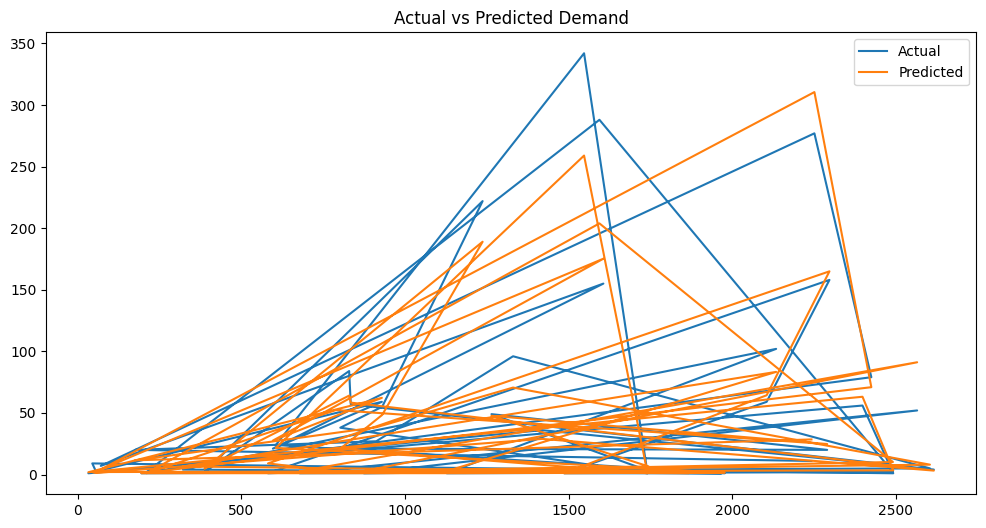

In [15]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

results = results.head(50)

results.plot(
    figsize=(12,6)
)

plt.title("Actual vs Predicted Demand")

plt.show()

In [16]:
joblib.dump(
    model,
    r"D:\Guvi\Projects\ride_flow_ai\models\demand_prediction_model.pkl"
)

print("Demand Model Saved")

Demand Model Saved
